# Personal Information
Name: **Elena Spano**

StudentID: **14444593**

Email: [**elena.spano@student.uva.nl**](youremail@student.uva.nl)

GitHub link: https://github.com/ele-spano22/master-thesis

Submitted on: **10.03.2026**

# Data Context
This thesis uses symbolic music datasets to investigate whether tonal mode (major vs. minor) is encoded in the internal representations of Transformer-based symbolic music models trained with a next-token prediction objective. The primary dataset used is the DCML corpus, an open-source collection of annotated classical music corpora curated by the DCMLab and available on GitHub. The corpus contains harmonic annotations, metadata, and symbolic music representations suitable for computational music analysis.

A secondary dataset is also used: the Essen Folksong available here: https://github.com/ccarh/essen-folksong-collection.


# Data Description

Dataset overview:

• Total pieces: 537
• Number of variables: 74
• Major pieces: 321 (59.8%)
• Minor pieces: 216 (40.2%)

Most common time signatures:
• 4/4
• 3/4
• 6/8

Piece lengths vary widely, with a median of X quarter beats.
Several metadata fields contain missing values related to editorial information and will not be used in further analysis.

# Data Description

**Present here the results of your exploratory data analysis. Note that there is no need to have a "story line" - it is more important that you show your understanding of the data and the methods that you will be using in your experiments (i.e. your methodology).**

**As an example, you could show data, label, or group balances, skewness, and basic characterizations of the data. Information about data frequency and distributions as well as results from reduction mechanisms such as PCA could be useful. Furthermore, indicate outliers and how/why you are taking them out of your samples, if you do so.**

**The idea is, that you conduct this analysis to a) understand the data better but b) also to verify the shapes of the distributions and whether they meet the assumptions of the methods that you will attempt to use. Finally, make good use of images, diagrams, and tables to showcase what information you have extracted from your data.**

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
from pathlib import Path

## Analysis 1: Dataset structure

### Data Loading

The data that I will be needing for this project is inside metadata files saved as metadata.tsv. Since the corpus contains 12 different corpora (divided by composer), there should be 12 metadata files. 

In [19]:
# loading all the metadata.tsv files in the corpus and inspecting them to find tonal mode encoding 
data_path = Path("../data/dcml_corpora")

metadata_files = list(data_path.rglob("metadata.tsv"))

len(metadata_files)


12

As expected, I am working with 12 metadata files. I will take a look at the column names to see where this info could be:

In [20]:
# inspecting the 12 metadata files to find a column that points me to tonal mode 

columns_by_corpus = {}

for file in metadata_files:
    
    df = pd.read_csv(file, sep="\t", nrows=5)
    
    corpus = file.parent.name
    columns_by_corpus[corpus] = df.columns.tolist()

columns_by_corpus

{'ABC': ['piece',
  'TimeSig',
  'KeySig',
  'last_mc',
  'last_mn',
  'length_qb',
  'last_mc_unfolded',
  'last_mn_unfolded',
  'length_qb_unfolded',
  'volta_mcs',
  'all_notes_qb',
  'n_onsets',
  'n_onset_positions',
  'guitar_chord_count',
  'form_label_count',
  'label_count',
  'annotated_key',
  'harmony_version',
  'annotators',
  'reviewers',
  'composed_start',
  'composed_end',
  'composer',
  'workTitle',
  'movementNumber',
  'movementTitle',
  'workNumber',
  'poet',
  'lyricist',
  'arranger',
  'copyright',
  'creationDate',
  'mscVersion',
  'platform',
  'source',
  'translator',
  'title_text',
  'lyricist_text',
  'composer_text',
  'musescore',
  'ms3_version',
  'subdirectory',
  'rel_path',
  'has_drumset',
  'ambitus',
  'comments',
  'originalFormat',
  'staff_1_ambitus',
  'staff_1_instrument',
  'staff_2_ambitus',
  'staff_2_instrument',
  'staff_3_ambitus',
  'staff_3_instrument',
  'staff_4_ambitus',
  'staff_4_instrument'],
 'grieg_lyric_pieces': ['piece

From the columns in the output, I can see 2 column with key in the name, "KeySig" and "annotated_key". I think the column with name "annotated_key" is probably the information I am looking for. However, I want to be sure that I am not missing oout on any other tonal mode information in the process, so I will simply index by "key" and see what I can find. 

In [21]:
for corpus, cols in columns_by_corpus.items():
    
    for c in cols:
        if "key" in c.lower():
            print(corpus, "→", c)

ABC → KeySig
ABC → annotated_key
grieg_lyric_pieces → KeySig
grieg_lyric_pieces → annotated_key
tchaikovsky_seasons → KeySig
tchaikovsky_seasons → annotated_key
debussy_suite_bergamasque → KeySig
debussy_suite_bergamasque → annotated_key
chopin_mazurkas → KeySig
chopin_mazurkas → annotated_key
chopin_mazurkas → key
liszt_pelerinage → KeySig
liszt_pelerinage → annotated_key
schumann_kinderszenen → KeySig
schumann_kinderszenen → annotated_key
dvorak_silhouettes → KeySig
dvorak_silhouettes → annotated_key
beethoven_piano_sonatas → KeySig
beethoven_piano_sonatas → annotated_key
corelli → KeySig
corelli → annotated_key
mozart_piano_sonatas → KeySig
mozart_piano_sonatas → annotated_key
medtner_tales → KeySig
medtner_tales → annotated_key


So indeed, for each corpora in the corpus, there are 2 columns with key in the names, KeySig and annotated_key. After inspecting KeySig, this is not the information I am looking for, so annotated_key is where tonal mode information about a given piece is stored. Let's see what it looks like:

In [27]:
metadata_list = []

for corpus in data_path.iterdir():
    
    if corpus.is_dir():
        
        metadata_file = corpus / "metadata.tsv"
        
        if metadata_file.exists():
            
            df = pd.read_csv(metadata_file, sep="\t")
            df["corpus"] = corpus.name
            
            metadata_list.append(df)

metadata = pd.concat(metadata_list, ignore_index=True)
metadata["annotated_key"].dropna().unique()[:20]

<StringArray>
[ 'F',  'd',  'G',  'C',  'D', 'Bb',  'c',  'A', 'Eb',  'f',  'e',  'E',  'a',
 'Ab', 'bb', 'Db', 'c#',  'b', 'g#', 'f#']
Length: 20, dtype: str

From what I can see above, tonal mode information is not explicit in the way it is stored, meaning it's not "minor" or "major". This is common in music notation. The uppercase letters indicate major pieces, while the lowercase letters indicate minor pieces. Key of course is specified by letter. That being said, it will be easier for me to conduct this EDA and interpret the results as well as the rest of the project if I turn this notation into explicit major vs. minor storage. In section 3, I will take the uppercase letters and assign them the label of "major" while I will assign the label of "minor" to lowercase letter, across all corpuses in the corpora (12). 

I will check other structural things about the dataset to make sure everything is in check before moving on. First let's look at the strcuture of our metadata.

In [82]:
metadata.shape

(537, 76)

We have 537 rows (meaning that 1 row = 1 piece) and 76 columns (1 column = musical characteristics per piece). I did this before to identify key information, but now let's print again the column names to see exactly what type of data is stored in our dataset, which will inform what kind of exploratory analyses we can perform later.

In [86]:
print(metadata.columns)

Index(['piece', 'TimeSig', 'KeySig', 'last_mc', 'last_mn', 'length_qb',
       'last_mc_unfolded', 'last_mn_unfolded', 'length_qb_unfolded',
       'volta_mcs', 'all_notes_qb', 'n_onsets', 'n_onset_positions',
       'guitar_chord_count', 'form_label_count', 'label_count',
       'annotated_key', 'harmony_version', 'annotators', 'reviewers',
       'composed_start', 'composed_end', 'composer', 'workTitle',
       'movementNumber', 'movementTitle', 'workNumber', 'poet', 'lyricist',
       'arranger', 'copyright', 'creationDate', 'mscVersion', 'platform',
       'source', 'translator', 'title_text', 'lyricist_text', 'composer_text',
       'musescore', 'ms3_version', 'subdirectory', 'rel_path', 'has_drumset',
       'ambitus', 'comments', 'originalFormat', 'staff_1_ambitus',
       'staff_1_instrument', 'staff_2_ambitus', 'staff_2_instrument',
       'staff_3_ambitus', 'staff_3_instrument', 'staff_4_ambitus',
       'staff_4_instrument', 'corpus', 'score_integrity', 'composed_source',
  

Looking at the available variables, we have a mixture of musical structure variables, analytical annotations, and editorial metadata. For the purposes of this thesis, the most relevant variables are those that describe musical properties of the pieces, which in this case are annotated_key, mode (which I just created myself), KeySig, and TimeSig, which provide tonal and metric information.Some other features that are more about the structure of a piece are length_qb, last_mc, last_mn, n_onsets, which describe aspects of the musical score like piece length, number of measures, and note density, which could be useful for EDA later. 

A large portion of the metadata though consists of editorial or bibliographic information, namely typesetter, transcriber, electronic editor, source, pdf, imslp, musicbrainz, wikidata, etc. These variables are not informative on musical content so they are not relevant for this analysis and will therefore be ignored in the following sections. There are also some text-related fields (title_text, lyricist_text, subtitle_text, etc.) that fall outside the scope of this study. 

Now let's look at how many pieces each corpus contains.

In [83]:
metadata["corpus"].value_counts()

corpus
corelli                      149
ABC                           70
grieg_lyric_pieces            66
beethoven_piano_sonatas       64
chopin_mazurkas               55
mozart_piano_sonatas          54
liszt_pelerinage              19
medtner_tales                 19
schumann_kinderszenen         13
tchaikovsky_seasons           12
dvorak_silhouettes            12
debussy_suite_bergamasque      4
Name: count, dtype: int64

Let's also check what variable types we are working with, so we know which variables we can later use for numerical analysis and how to access them.

In [87]:
metadata.dtypes

piece                   str
TimeSig                 str
KeySig                  str
last_mc               int64
last_mn               int64
                      ...  
transcriber             str
electronic editor       str
electronic encoder      str
tonic                   str
timesig_simple          str
Length: 76, dtype: object

## Analysis 2: Missing values

Let's check if there are any missing values/other issues to address.

In [92]:
metadata.isna().sum().sort_values(ascending=False)

transcriber           537
translator            537
arranger              537
poet                  537
lyricist              536
text                  533
imslp.1               532
comments              531
PDF                   518
electronic encoder    514
lyricist_text         514
electronic editor     514
score integrity       513
key                   482
typesetter            465
volta_mcs             455
staff_4_instrument    418
pdf                   415
viaf                  402
staff_3_instrument    398
source                390
score_integrity       374
copyright             355
staff_4_ambitus       332
staff_3_ambitus       312
composed_source       273
wikidata              257
imslp                 219
musicbrainz           219
creationDate          149
platform              149
subtitle_text         131
staff_2_instrument    119
staff_1_instrument    119
movementTitle          95
movementNumber         75
workNumber             70
reviewers              69
workTitle   

As we can see, many of the columns in the dataset are completely empty and some are mostly empty. This is okay since I will not be needing any of this information for my project. Therefore, I will remove the empty columsn completely from the dataset as they serve no purpose but I will keep the ones that contain information across a portion of the pieces.

In [96]:
empty_cols = metadata.columns[metadata.isna().sum() == len(metadata)]
metadata = metadata.drop(columns=empty_cols)


### Missing values (for annotated key)

In [62]:
metadata["annotated_key"].isna().sum()

np.int64(0)

As we can see, there are (I ran the cell above after removing them already so that's why it says 0 now) 23 missing values in the annotated_key column across the dataset. 

I will drop these rows from the dataset and then classify annotated_key as major or minor to obtain my labels. This decision is made on the basis of the fact that I simply cannot derive tonal mode without an explicit key label, so these rows are of no use to me. Since there are 560 pieces in the dataset, removing 23 is taking out a very very small portion of the dataset (less than 4%), so I am okay with dropping these rows.

In [97]:
metadata = metadata.dropna(subset=["annotated_key"])

In [98]:
print("Dataset size after removing missing keys:", metadata.shape)

Dataset size after removing missing keys: (537, 72)


Now our datasets contains 537 rows (pieces) and 74 columns (musical attributes) for the annotated_key column. 

### Missing values (for instrument type)

We have the variable staff_1_instrument, which contains information on the instrument used for a musical piece. This could be a very interesting variable for our EDA, so let's check if it requires any cleaning and what it looks like so we can work with it later.

In [129]:
metadata["staff_1_instrument"].value_counts()

staff_1_instrument
Piano                 98
piano                 73
Violin                58
Midi_1                42
Piano (2)             36
organ                 24
Klavier linke Hand    23
StringInstrument      23
MusicXML Default 1    16
Violin I (2)          12
unbenannt2             6
unbenannt              4
Grand Piano            1
S.                     1
Klavier                1
Name: count, dtype: int64

The current issue with this list of instruments is that many names point to the same instrument (piano) but appear as different categories, which is wrong. There are also entries that do not point to actual instruments but simply to encoding artifacts (like Midi_1), which we should ignore. I will group all names falling into the category of piano into 1 and normalize the other entries.

In [133]:
metadata["instrument_clean"] = metadata["staff_1_instrument"].str.lower()
metadata["instrument_clean"] = metadata["instrument_clean"].replace({
    
    "piano": "piano",
    "grand piano": "piano",
    "piano (2)": "piano",
    "klavier": "piano",
    "klavier linke hand": "piano",
    
    "violin": "violin",
    "violin i (2)": "violin",
    
    "organ": "organ",
    
    "stringinstrument": "string",
    
    "midi_1": "unknown",
    "musicxml default 1": "unknown",
    "unbenannt": "unknown",
    "unbenannt2": "unknown",
    "s.": "unknown"
})
metadata["instrument_clean"].value_counts()

instrument_clean
piano      232
violin      70
unknown     69
organ       24
string      23
Name: count, dtype: int64

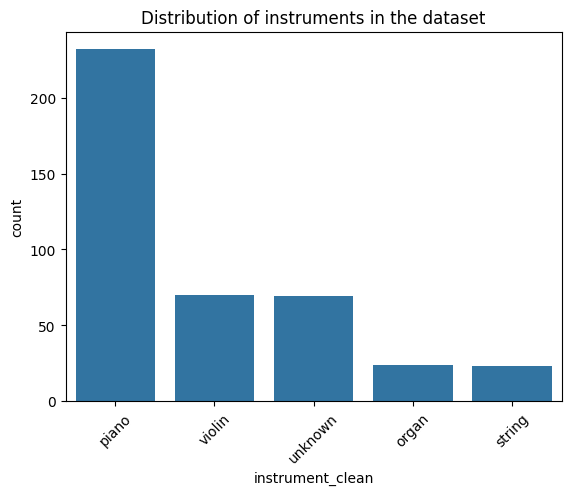

In [134]:
sns.countplot(
    data=metadata,
    x="instrument_clean",
    order=metadata["instrument_clean"].value_counts().index
)

plt.title("Distribution of instruments in the dataset")
plt.xticks(rotation=45)

plt.show()

Now, the instrument variable is usable for our analysis. It is clear however that most of the dataset contains piano pieces, which makes the distribution imbalanced. I will keep this in mind as I utilize this variable.

## Analysis x: Basic statistics

Now I will compute basic statistics for our numerical variables. This is good for getting an idea of the distributions of my numerical variables.

In [89]:
metadata.describe()

,last_mc,last_mn,length_qb,last_mc_unfolded,last_mn_unfolded,length_qb_unfolded,all_notes_qb,n_onsets,n_onset_positions,guitar_chord_count,form_label_count,label_count,composed_start,composed_end,movementNumber,poet,arranger,mscVersion,translator
count,537.000000,537.000000,537.000000,535.000000,535.000000,535.000000,537.000000,537.000000,537.000000,537.000000,537.0,537.000000,537.000000,537.000000,462.000000,0.0,0.0,5.360000e+02,0.0
mean,108.573557,107.983240,337.106592,140.095327,139.009346,434.042972,1068.762998,1537.646182,741.188082,0.009311,0.0,214.392924,1793.752328,1794.832402,3.006494,NaN,NaN,3.020000e+00,NaN
std,98.597812,98.290679,311.535773,127.464368,126.616092,398.380013,984.046367,1480.799094,712.886593,0.113898,0.0,164.824602,74.311517,75.266082,2.089630,NaN,NaN,4.445041e-16,NaN
min,2.000000,2.000000,8.000000,2.000000,2.000000,8.000000,12.000000,12.000000,4.000000,0.000000,0.0,4.000000,1681.000000,1681.000000,1.000000,NaN,NaN,3.020000e+00,NaN
25%,39.000000,38.000000,135.000000,54.000000,54.000000,173.750000,444.000000,519.000000,235.000000,0.000000,0.0,95.000000,1694.000000,1694.000000,2.000000,NaN,NaN,3.020000e+00,NaN
50%,75.000000,74.000000,222.000000,90.000000,90.000000,300.000000,718.580000,999.000000,461.000000,0.000000,0.0,156.000000,1802.000000,1802.000000,3.000000,NaN,NaN,3.020000e+00,NaN
75%,151.000000,150.000000,432.000000,193.500000,192.500000,558.500000,1380.330000,2054.000000,1073.000000,0.000000,0.0,295.000000,1843.000000,1846.000000,4.000000,NaN,NaN,3.020000e+00,NaN
max,554.000000,553.000000,2000.000000,672.000000,664.000000,2192.000000,5885.890000,11682.000000,4586.000000,2.000000,0.0,871.000000,1925.000000,1925.000000,13.000000,NaN,NaN,3.020000e+00,NaN


### Piece lenght distribution

I will also use a histogram to visualize, overall, the lenght of our corpora pieces. This will tell us whether the pieces in the dataset are short or long (on a spectrum, that is).

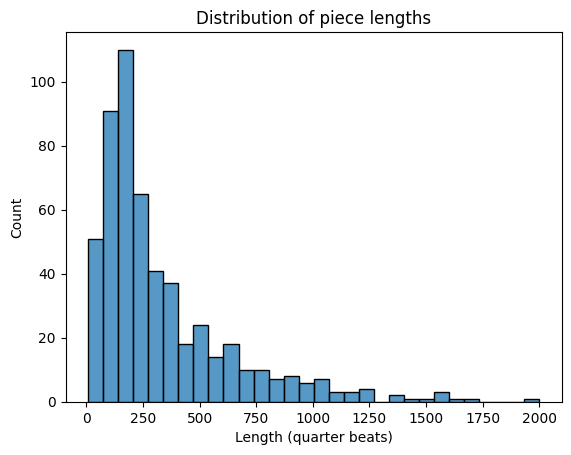

In [90]:
sns.histplot(metadata["length_qb"], bins=30)
plt.title("Distribution of piece lengths")
plt.xlabel("Length (quarter beats)")
plt.show()

## Analysis 3: Creating class labels

Now that I have a better understanding of the data I am working with and I removed all missing values from annotated_key, I can create my major vs. minor labels.

In [104]:
# here, I extract the first character of the key label and check if it is uppercase
# If it is uppercase → major
# If it is lowercase → minor

metadata["mode"] = metadata["annotated_key"].str[0].str.isupper().map({
    True: "major",
    False: "minor"
})

# check the distribution of major vs minor pieces in the dataset.
metadata["mode"].value_counts(dropna=False)
metadata[["annotated_key", "mode"]].head(10)

,annotated_key,mode
0,F,major
1,d,minor
2,F,major
3,F,major
4,G,major
5,C,major
6,G,major
7,G,major
8,D,major
9,Bb,major


In [110]:
print(metadata[["mode"]].shape)

(537, 1)


The next thing I need to check is class balance. Oftentimes in music, pieces tend to be major more often than they are minor. This can cause issues during model training and testing, so it is good to check the distribution now. 

In [67]:
print(metadata["mode"].value_counts())
print(metadata["mode"].value_counts(normalize=True))


mode
major    321
minor    216
Name: count, dtype: int64
mode
major    0.597765
minor    0.402235
Name: proportion, dtype: float64


I will also visualize this result with a simple plot with seaborn.

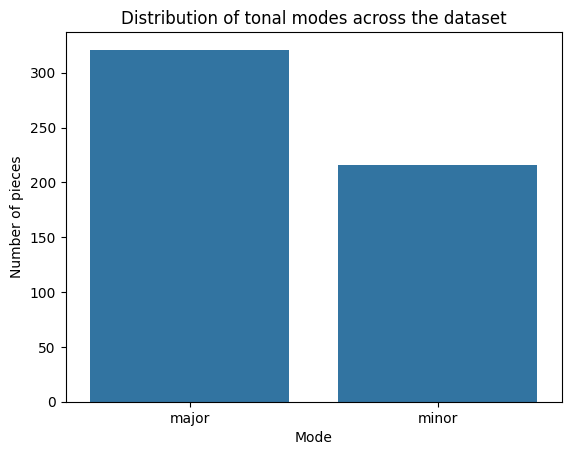

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=metadata, x="mode")
plt.title("Distribution of tonal modes across the dataset")
plt.xlabel("Mode")
plt.ylabel("Number of pieces")
plt.show()

As we can see, the dataset contains 321 major pieces (59.8%) and 216 minor pieces (40.2%). This is not as bad as I expected, it does indicate a mild class imbalance but there is definetely enough representation of both classes and is not imbalanced to a problematic level.

### Creating a variable for tonic 

It will also be useful for me for later analysis to have a variable that contains tonic information. That is, currently annotated_key contains 2 pieces of information at once: tonic (A, B, C, etc.) and tonal mode (encoded in uppercase/lowercase). I already created a variable that explicitly labels a piece as major or minor, so now I want to create a variable that assigns one tonic to each piece, based on the tonic in the annotated_key column. This is just a mor straightforward way to access both information pieces, tonal mode and tonic as 2 separate concepts.

In [117]:
metadata["tonic"] = metadata["annotated_key"].str.capitalize()
metadata[["annotated_key", "tonic", "mode"]].head(20)

,annotated_key,tonic,mode
0,F,F,major
1,d,D,minor
2,F,F,major
3,F,F,major
4,G,G,major
5,C,C,major
6,G,G,major
7,G,G,major
8,D,D,major
9,Bb,Bb,major


### Number of pieces per corpus

Another thing that is good to check is the distribution of pieces per corpus. Some composers have much bigger portfolios than others, so it is expected that some of the corpuses will contain more pieces than others.

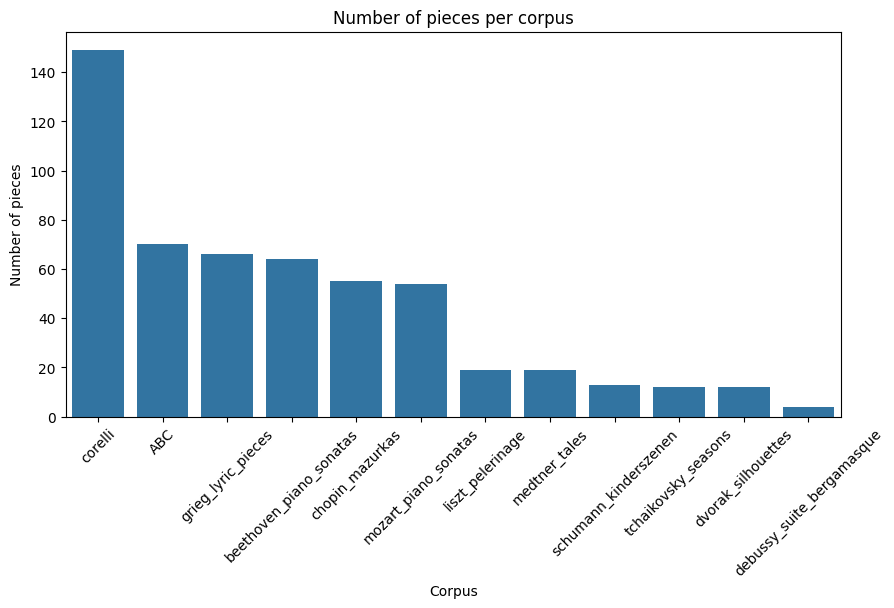

In [71]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=metadata,
    x="corpus",
    order=metadata["corpus"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Number of pieces per corpus")
plt.xlabel("Corpus")
plt.ylabel("Number of pieces")

plt.show()

## Analysis 4: Tonal mode distribution (across corpuses)

The next thing to do is to check the distribution of tonal mode across corpuses (as a reminder, each corpus represents an individual composer). Generally speaking, there are composers that are known to write more major or minor pieces, so it is interesting to check this.

In [69]:
counts = pd.crosstab(metadata["corpus"], metadata["mode"])
display(counts)

percentages = pd.crosstab(metadata["corpus"], metadata["mode"], normalize="index") * 100
display(percentages.round(1))

mode,major,minor
corpus,,
ABC,49,21
beethoven_piano_sonatas,45,19
chopin_mazurkas,28,27
corelli,72,77
debussy_suite_bergamasque,2,2
dvorak_silhouettes,7,5
grieg_lyric_pieces,35,31
liszt_pelerinage,13,6
medtner_tales,5,14


mode,major,minor
corpus,,
ABC,70.0,30.0
beethoven_piano_sonatas,70.3,29.7
chopin_mazurkas,50.9,49.1
corelli,48.3,51.7
debussy_suite_bergamasque,50.0,50.0
dvorak_silhouettes,58.3,41.7
grieg_lyric_pieces,53.0,47.0
liszt_pelerinage,68.4,31.6
medtner_tales,26.3,73.7


Indeed, as expected, there are composers who mainly wrote major pieces (Mozart, Beethoven, ABC composers, Schumann, Listz), others whose distribution is fairly balanced (Chopin, Corelli, Debussy, Dvorak, Grieg), and others who mainly wrote minor pieces (Medtner). We can also visualize this as so:

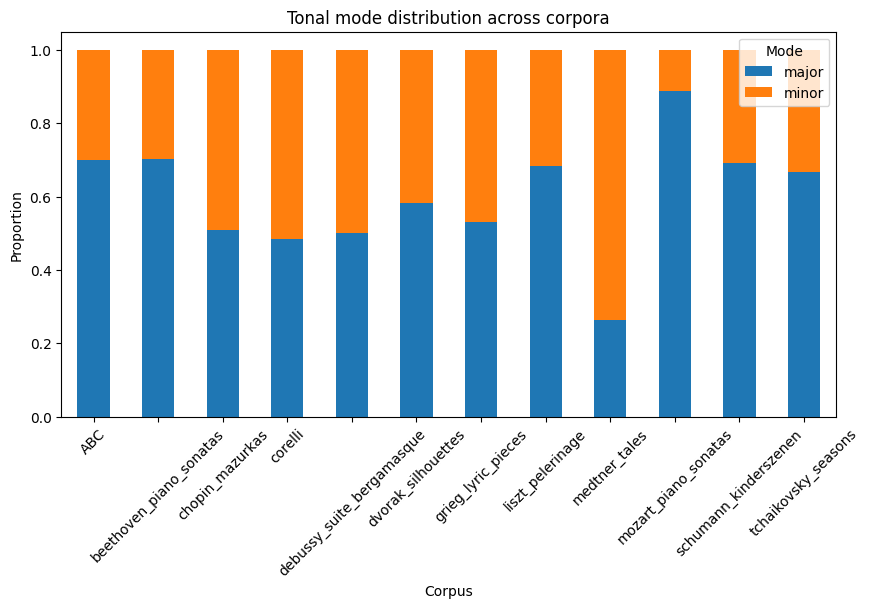

In [73]:
mode_corpus = pd.crosstab(
    metadata["corpus"],
    metadata["mode"],
    normalize="index"
)

mode_corpus.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Tonal mode distribution across corpora")
plt.ylabel("Proportion")
plt.xlabel("Corpus")

plt.xticks(rotation=45)
plt.legend(title="Mode")

plt.show()

### Key distribution (across corpuses)

Another thing that is good to take a look at is key distribution across corpuses. 

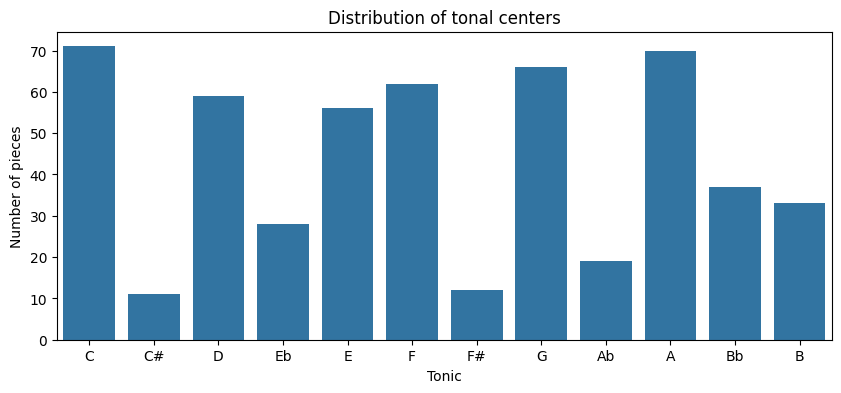

In [ ]:
key_order = [
    "C","C#","D","Eb","E","F",
    "F#","G","Ab","A","Bb","B"
]
plt.figure(figsize=(10,4))

sns.countplot(
    data=metadata,
    x="tonic",
    order=key_order
)

plt.title("Distribution of tonal centers")
plt.xlabel("Tonic")
plt.ylabel("Number of pieces")

plt.show()

## Analysis 5: Multivariate analysis 

## *Categorical interactions*

### Tonic by key

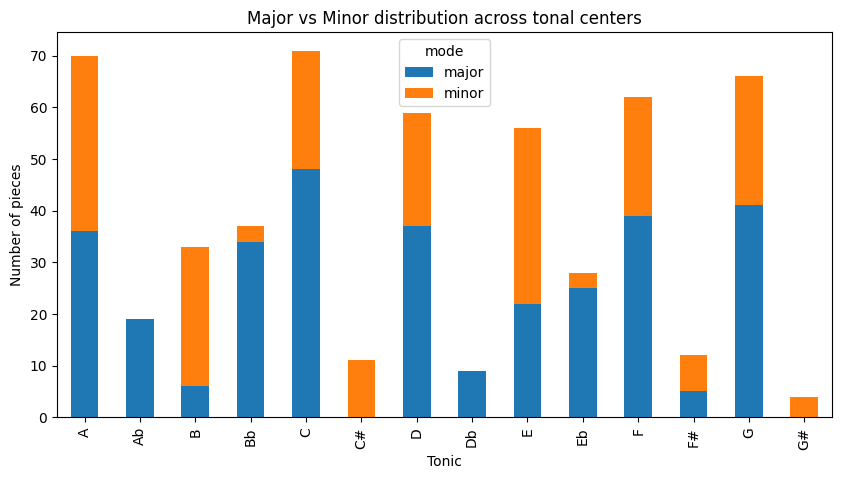

In [75]:
key_mode = pd.crosstab(metadata["tonic"], metadata["mode"])
key_mode.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("Major vs Minor distribution across tonal centers")
plt.xlabel("Tonic")
plt.ylabel("Number of pieces")

plt.show()

### Tonal mode by corpus

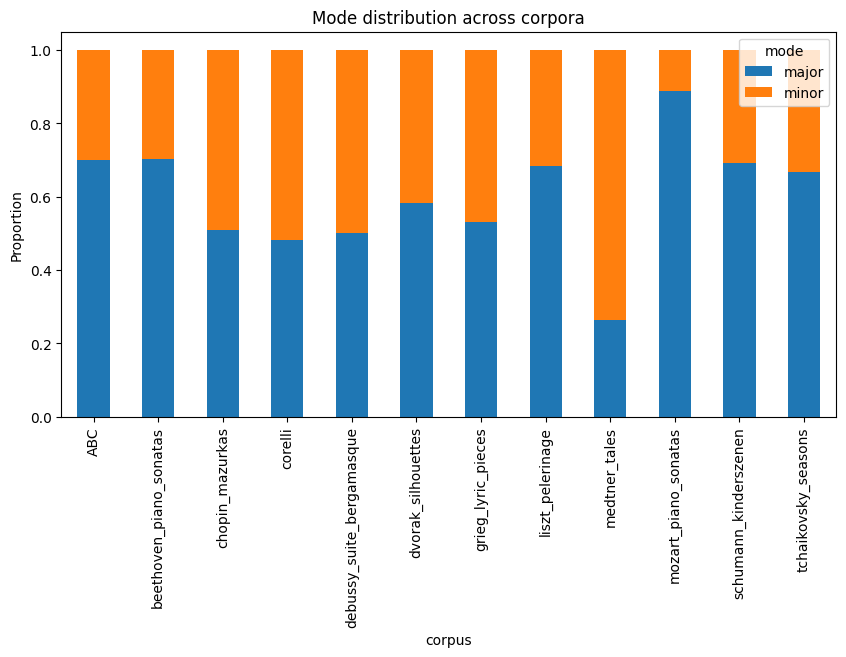

In [76]:
corpus_mode = pd.crosstab(metadata["corpus"], metadata["mode"], normalize="index")
corpus_mode.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("Mode distribution across corpora")
plt.ylabel("Proportion")

plt.show()

### Tonic by corpus

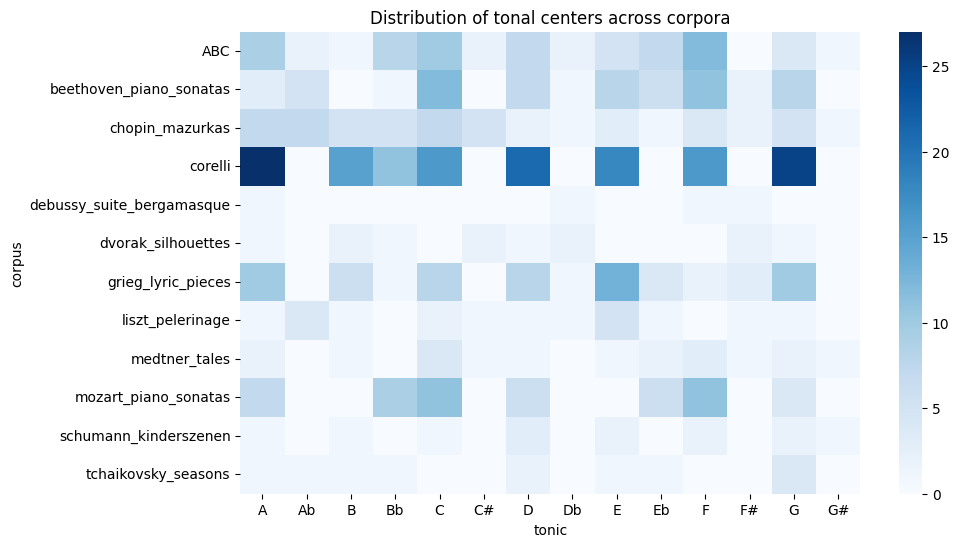

In [77]:
pd.crosstab(metadata["corpus"], metadata["tonic"])
key_corpus = pd.crosstab(metadata["corpus"], metadata["tonic"])

plt.figure(figsize=(10,6))

sns.heatmap(key_corpus, cmap="Blues")

plt.title("Distribution of tonal centers across corpora")

plt.show()

### Time signature by tonal mode 

<Axes: xlabel='timesig_simple'>

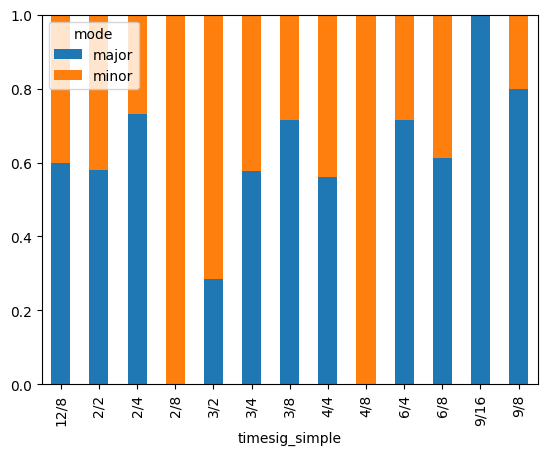

In [78]:
metadata["timesig_simple"] = metadata["TimeSig"].str.extract(r'(\d+/\d+)')
pd.crosstab(metadata["timesig_simple"], metadata["mode"])
pd.crosstab(metadata["timesig_simple"], metadata["mode"], normalize="index").plot(
    kind="bar",
    stacked=True
)

### Piece lenght by tonal mode

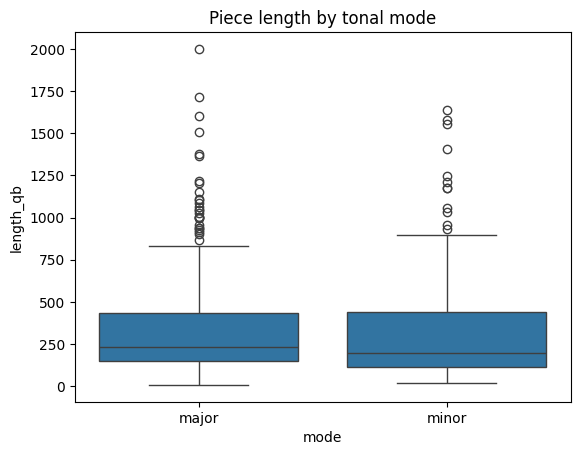

In [79]:
sns.boxplot(data=metadata, x="mode", y="length_qb")

plt.title("Piece length by tonal mode")

plt.show()

### Instrument by tonal mode

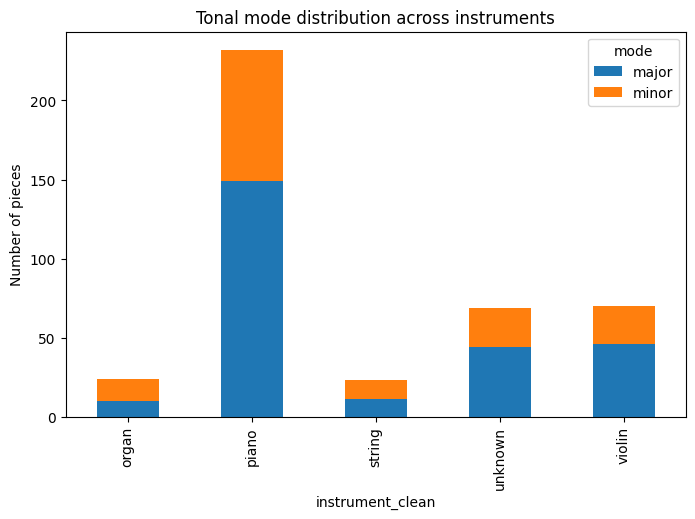

In [136]:
instrument_mode = pd.crosstab(
    metadata["instrument_clean"],
    metadata["mode"]
)

instrument_mode.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Tonal mode distribution across instruments")
plt.ylabel("Number of pieces")

plt.show()

### Instrument by tonic (normalized by row)

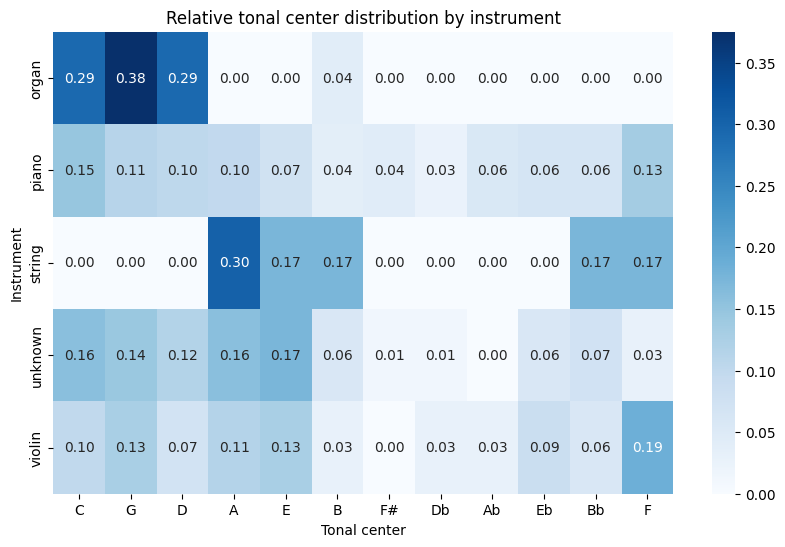

In [142]:
instrument_key_norm = pd.crosstab(
    metadata["instrument_clean"],
    metadata["tonic"],
    normalize="index"
)

key_order = [
    "C","G","D","A","E","B",
    "F#","Db","Ab","Eb","Bb","F"
]
instrument_key_norm = instrument_key_norm.reindex(columns=key_order)

plt.figure(figsize=(10,6))

sns.heatmap(
    instrument_key_norm,
    cmap="Blues",
    annot=True,
    fmt=".2f"
)

plt.title("Relative tonal center distribution by instrument")
plt.xlabel("Tonal center")
plt.ylabel("Instrument")

plt.show()

### Tonic by tonal mode by corpus

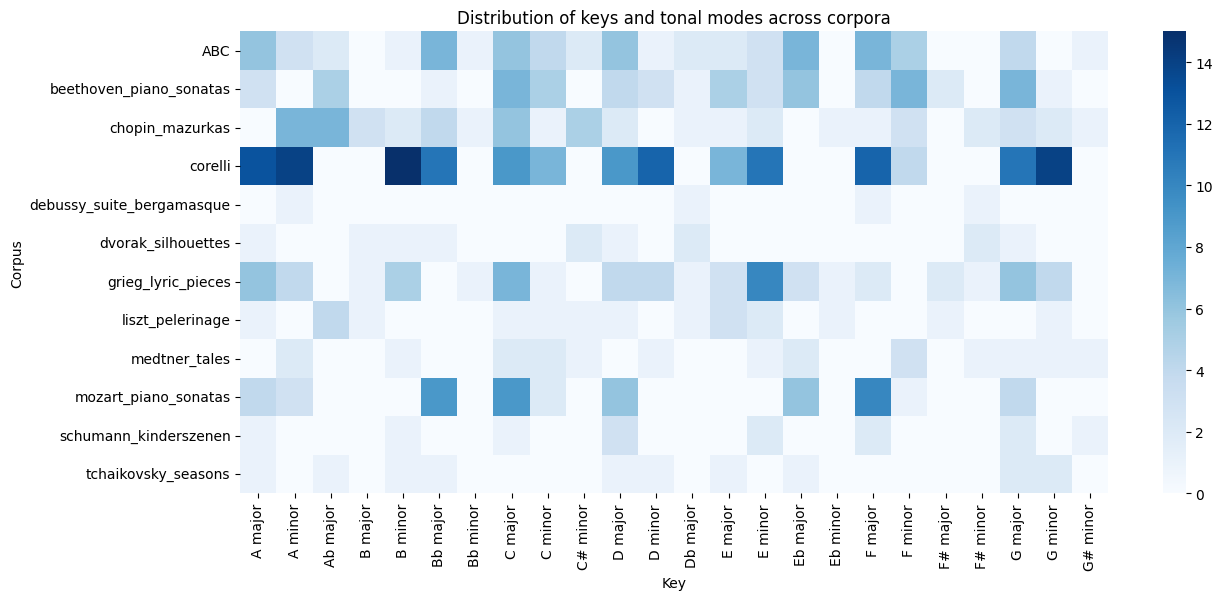

In [145]:
metadata["key_mode"] = metadata["tonic"] + " " + metadata["mode"]
corpus_keymode = pd.crosstab(
    metadata["corpus"],
    metadata["key_mode"]
)

plt.figure(figsize=(14,6))

sns.heatmap(
    corpus_keymode,
    cmap="Blues"
)

plt.title("Distribution of keys and tonal modes across corpora")
plt.xlabel("Key")
plt.ylabel("Corpus")

plt.show()

## *Numerical relationships*

### Correlation between numerical variables

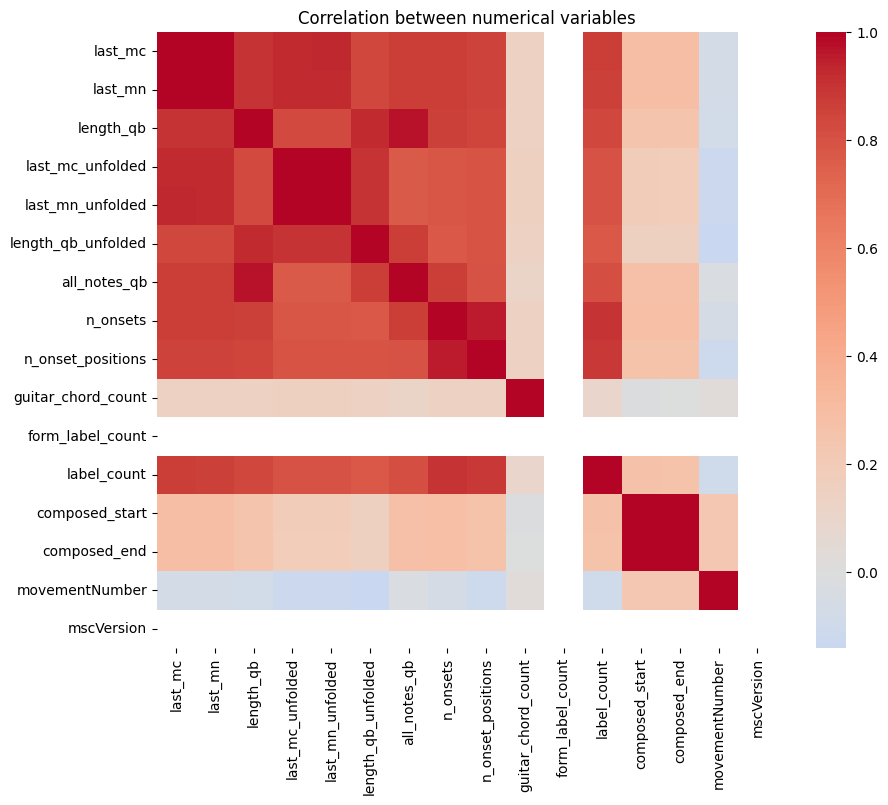

In [120]:
numeric_cols = metadata.select_dtypes(include=["int64","float64"])
corr = numeric_cols.corr()
plt.figure(figsize=(10,8))

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Correlation between numerical variables")

plt.show()

## *Numerical vs categorical*

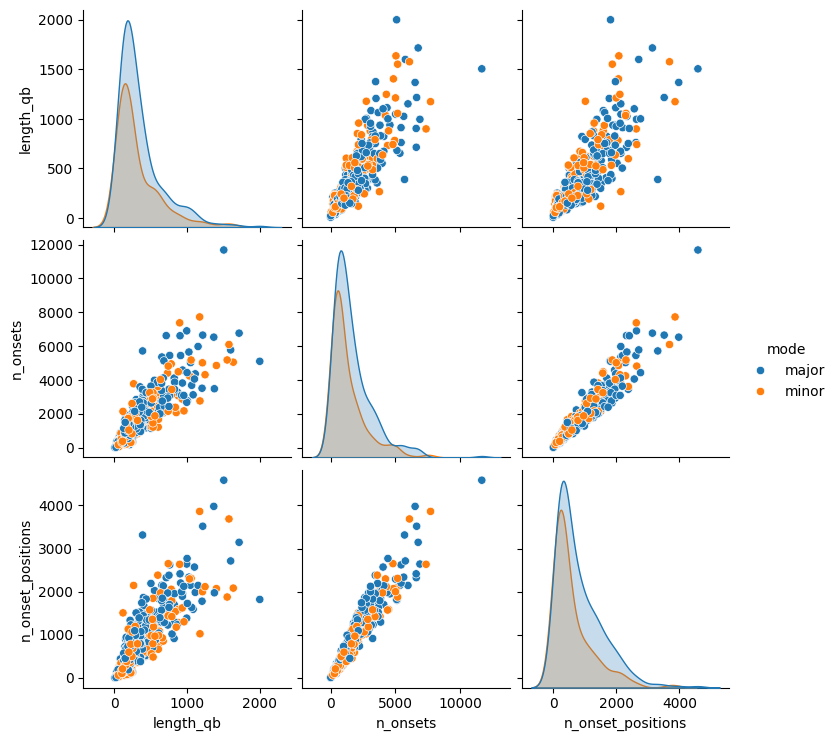

In [121]:
subset = metadata[
    ["length_qb","n_onsets","n_onset_positions","mode"]
]

sns.pairplot(subset, hue="mode")

plt.show()

## *Statistical testing*

### Statistical test for differences in piece lenght between major and minor pieces

In [123]:
from scipy.stats import ttest_ind

major = metadata[metadata["mode"]=="major"]["length_qb"]
minor = metadata[metadata["mode"]=="minor"]["length_qb"]

ttest_ind(major, minor)

TtestResult(statistic=np.float64(1.2795895035565115), pvalue=np.float64(0.20124417333264466), df=np.float64(535.0))

### Statistical test for differences in tonic between major and minor pieces

In [127]:
from scipy.stats import chi2_contingency

table = pd.crosstab(metadata["tonic"], metadata["mode"])

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 8.036722023352312e-17


### Statistical test for differences in tonal mode across different instruments

In [137]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(instrument_mode)

print("p-value:", p)

p-value: 0.12721678682444243


### Analysis 6: Baseline

### *Simple baseline: majority classifier*

For the baseline, I will compute a simple majority-class baseline.

In [118]:
class_distribution = metadata["mode"].value_counts(normalize=True)

baseline_accuracy = class_distribution.max()

print("Class distribution:")
print(class_distribution)

print("\nMajority class baseline accuracy:")
print(round(baseline_accuracy, 3))

Class distribution:
mode
major    0.597765
minor    0.402235
Name: proportion, dtype: float64

Majority class baseline accuracy:
0.598


Since the dataset contains 321 major pieces (59.8%) and 216 minor pieces (40.2%), a simple classifier that always predicts the majority class (major) would then achieve an accuracy of approximately 59.8%. Naturally, any predictive model that I will train in the main analysis would ideally exceed this performance to demonstrate meaningful predictive power.

##